In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carga del Dataset y exploracion de variables

In [ ]:
df = pd.read_csv('../data/dataset.csv')

In [20]:
# Informacion basica del dataset
print('Informacion del dataset:')
print("="*50)
print(f"Forma del dataset: {df.shape}")
print(f"Columnas del dataset: \n{df.columns}")
# print(df.head())
print(f"Valores nulos: \n{df.isnull().sum()}")


Informacion del dataset:
Forma del dataset: (1338, 7)
Columnas del dataset: 
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')
Valores nulos: 
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [23]:
print("\nSummary de info del archivo\n")
print (df.info())



Summary de info del archivo

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [45]:
df.duplicated().sum()
df[df.duplicated(keep=False)]
df=df.drop_duplicates()
df.shape[0]

1337

In [46]:
# Descripcion de variables numericas
print (df.describe())

               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010


In [47]:
# Estadísticas para variables categóricas
print("\nDistribución de variables categóricas:")
for col in ['sex', 'smoker', 'region']:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Proporción:\n{df[col].value_counts(normalize=True)}")


Distribución de variables categóricas:

sex:
sex
male      675
female    662
Name: count, dtype: int64
Proporción:
sex
male      0.504862
female    0.495138
Name: proportion, dtype: float64

smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64
Proporción:
smoker
no     0.795064
yes    0.204936
Name: proportion, dtype: float64

region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64
Proporción:
region
southeast    0.272251
southwest    0.243082
northwest    0.242334
northeast    0.242334
Name: proportion, dtype: float64


### Visualizaciones

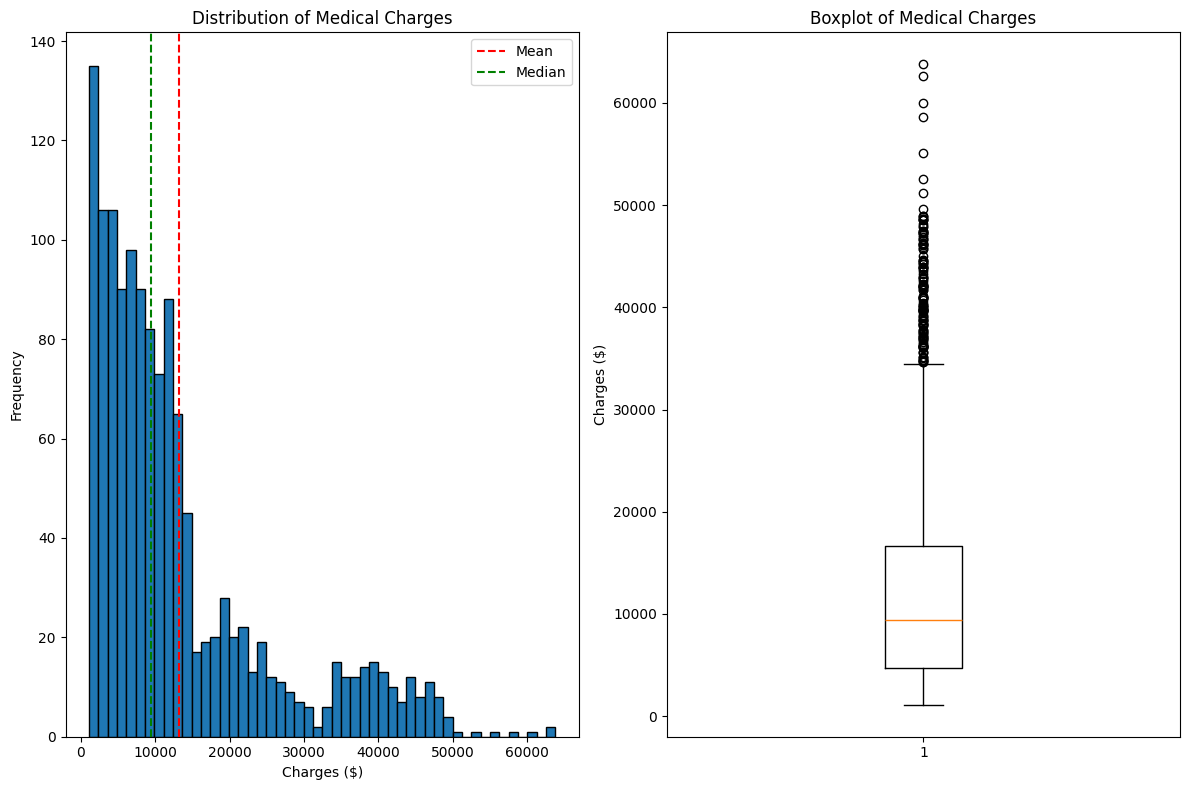

In [48]:
fig,axes = plt.subplots(1,2,figsize=(12,8))

# Histograma
axes[0].hist(df['charges'], bins=50, edgecolor='black')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Medical Charges')
axes[0].axvline(df['charges'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(df['charges'].median(), color='green', linestyle='--', label='Median')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['charges'])
axes[1].set_ylabel('Charges ($)')
axes[1].set_title('Boxplot of Medical Charges')

plt.tight_layout()
plt.show()

### Distribucion de variables numericas


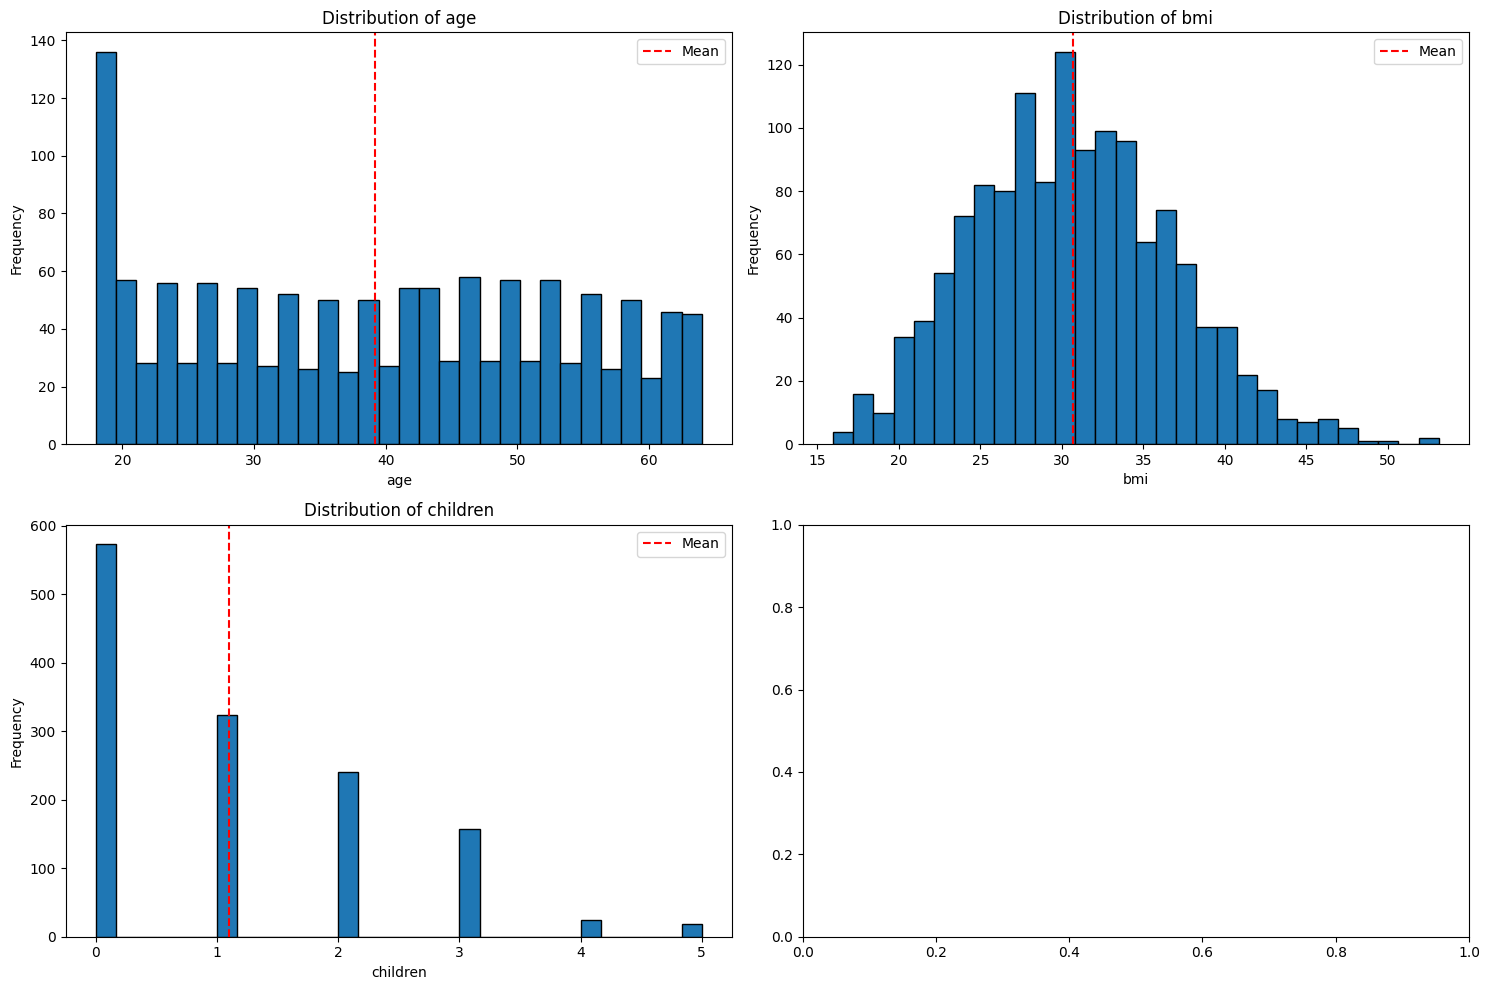

In [49]:

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(['age', 'bmi', 'children']):
    axes[idx].hist(df[col], bins=30, edgecolor='black')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[idx].legend()

plt.tight_layout()
plt.show()

### Analisis de correlaciones


               age       sex       bmi  children    smoker   charges
age       1.000000 -0.019814  0.109344  0.041536 -0.025587  0.298308
sex      -0.019814  1.000000  0.046397  0.017848  0.076596  0.058044
bmi       0.109344  0.046397  1.000000  0.012755  0.003746  0.198401
children  0.041536  0.017848  0.012755  1.000000  0.007331  0.067389
smoker   -0.025587  0.076596  0.003746  0.007331  1.000000  0.787234
charges   0.298308  0.058044  0.198401  0.067389  0.787234  1.000000


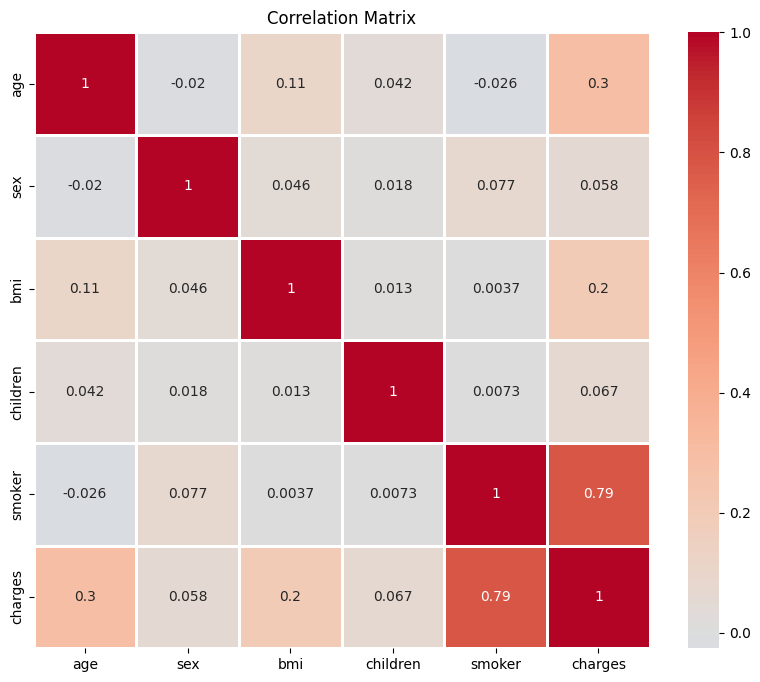


Correlación con charges:
charges     1.000000
smoker      0.787234
age         0.298308
bmi         0.198401
children    0.067389
sex         0.058044
Name: charges, dtype: float64


In [50]:

# Codificar variables categóricas para correlación
df_encoded = df.copy()
df_encoded['sex'] = (df_encoded['sex'] == 'male').astype(int)
df_encoded['smoker'] = (df_encoded['smoker'] == 'yes').astype(int)
df_encoded['region'] = df_encoded['region'].astype('category').cat.codes

correlation_matrix = df_encoded[['age', 'sex', 'bmi', 'children', 'smoker', 'charges']].corr()
print(correlation_matrix)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Correlation Matrix')
plt.show()

print("\nCorrelación con charges:")
print(correlation_matrix['charges'].sort_values(ascending=False))

### Analisis por grupos

/tmp/ipykernel_658395/79861048.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([df[df['sex']=='male']['charges'],
/tmp/ipykernel_658395/79861048.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([df[df['smoker']=='no']['charges'],
/tmp/ipykernel_658395/79861048.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(region_data, labels=regions)
/tmp/ipykernel_658395/79861048.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 

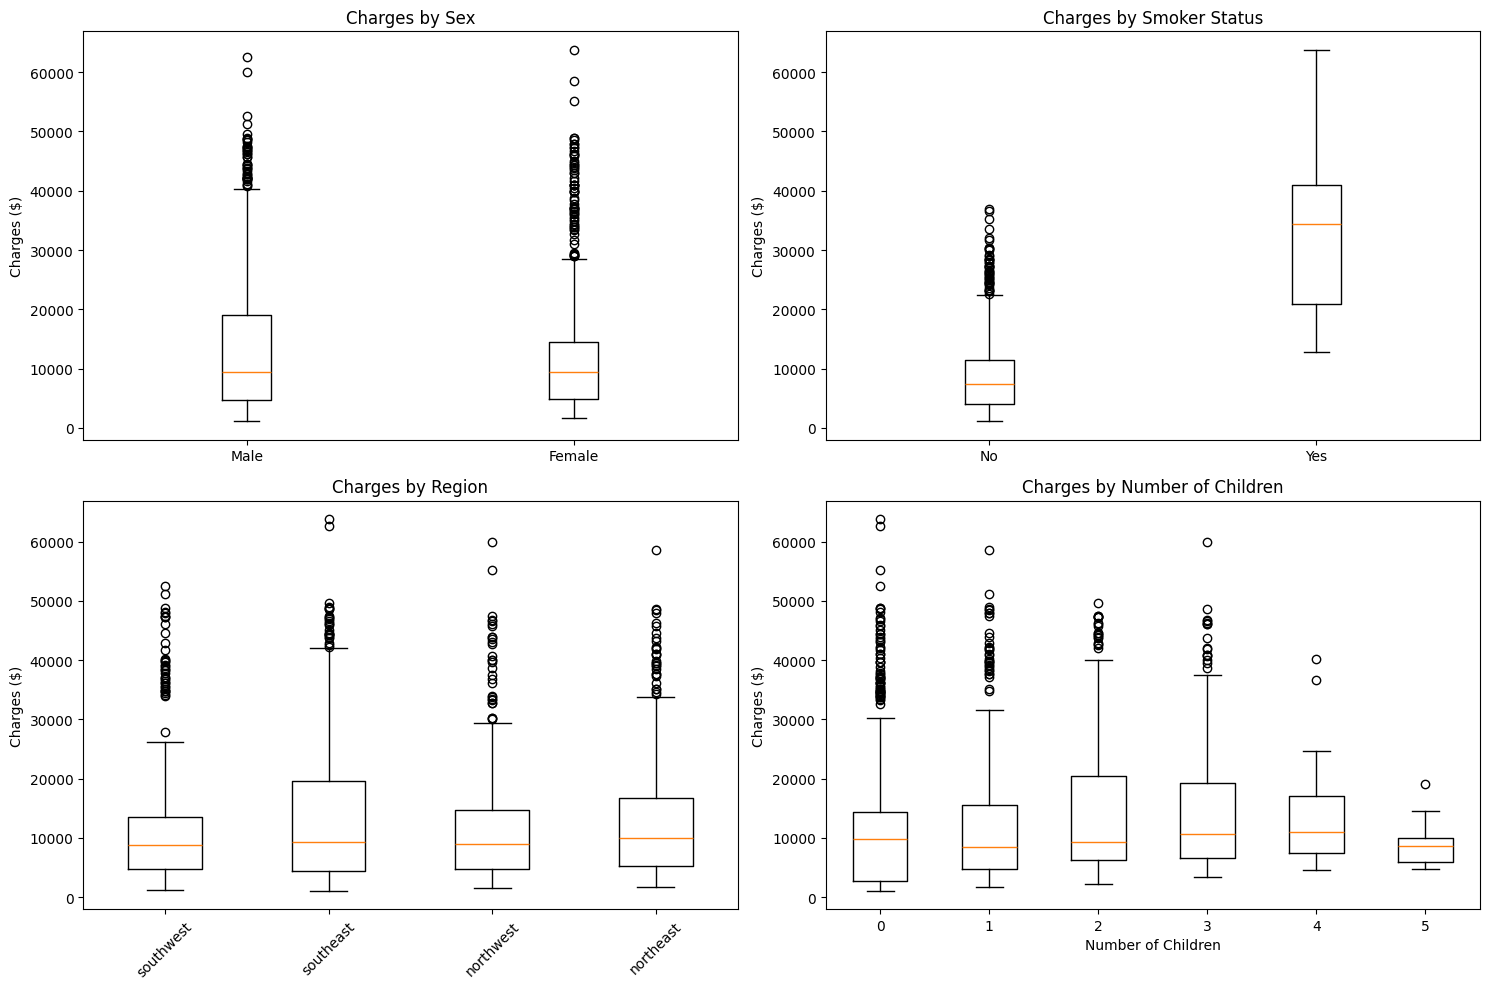

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Sex
axes[0, 0].boxplot([df[df['sex']=='male']['charges'], 
                     df[df['sex']=='female']['charges']],
                    labels=['Male', 'Female'])
axes[0, 0].set_ylabel('Charges ($)')
axes[0, 0].set_title('Charges by Sex')

# Smoker (VARIABLE MÁS IMPORTANTE)
axes[0, 1].boxplot([df[df['smoker']=='no']['charges'], 
                     df[df['smoker']=='yes']['charges']],
                    labels=['No', 'Yes'])
axes[0, 1].set_ylabel('Charges ($)')
axes[0, 1].set_title('Charges by Smoker Status')

# Region
regions = df['region'].unique()
region_data = [df[df['region']==r]['charges'] for r in regions]
axes[1, 0].boxplot(region_data, labels=regions)
axes[1, 0].set_ylabel('Charges ($)')
axes[1, 0].set_title('Charges by Region')
axes[1, 0].tick_params(axis='x', rotation=45)

# Children
children_counts = sorted(df['children'].unique())
children_data = [df[df['children']==c]['charges'] for c in children_counts]
axes[1, 1].boxplot(children_data, labels=children_counts)
axes[1, 1].set_xlabel('Number of Children')
axes[1, 1].set_ylabel('Charges ($)')
axes[1, 1].set_title('Charges by Number of Children')

plt.tight_layout()
plt.show()

In [52]:
# Estadísticas por smoker por ser grupo más relevante
print("\nCharges por Smoker Status:")
print(df.groupby('smoker')['charges'].describe())


Charges por Smoker Status:
         count          mean           std         min           25%  \
smoker                                                                 
no      1063.0   8440.660307   5992.973800   1121.8739   3988.883500   
yes      274.0  32050.231832  11541.547176  12829.4551  20826.244213   

                50%           75%          max  
smoker                                          
no       7345.72660  11363.019100  36910.60803  
yes     34456.34845  41019.207275  63770.42801  


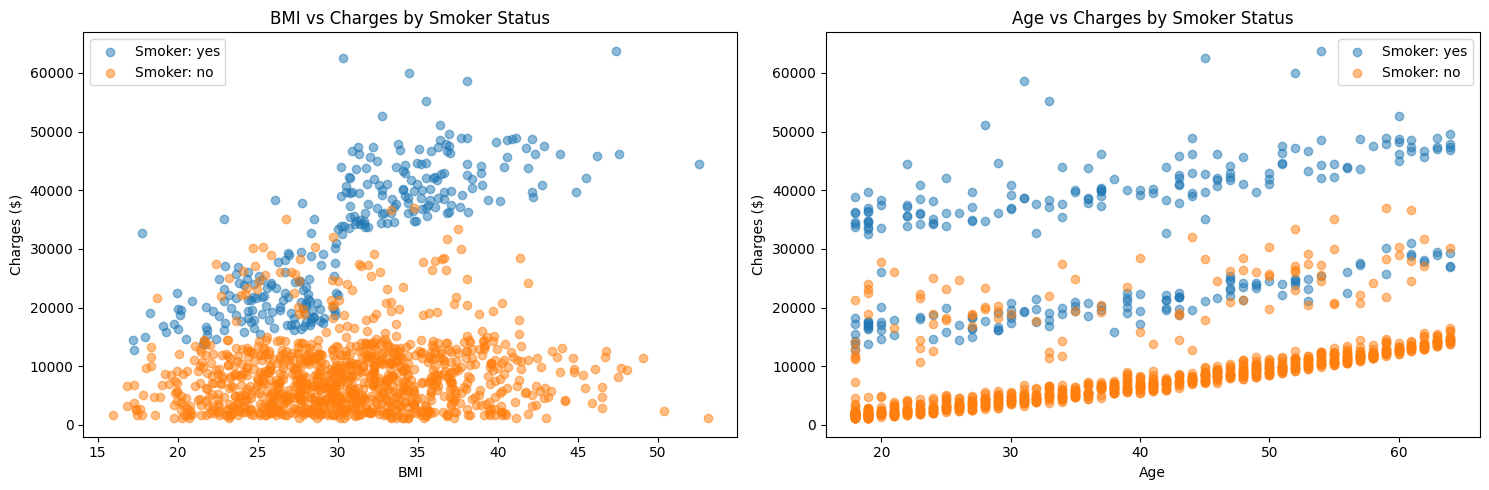

In [53]:
# Interacción: Smoker × BMI (CRÍTICA)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot
for smoker in ['yes', 'no']:
    data = df[df['smoker'] == smoker]
    axes[0].scatter(data['bmi'], data['charges'], 
                    alpha=0.5, label=f"Smoker: {smoker}")
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Charges ($)')
axes[0].set_title('BMI vs Charges by Smoker Status')
axes[0].legend()

# Interacción: Age × Smoker
for smoker in ['yes', 'no']:
    data = df[df['smoker'] == smoker]
    axes[1].scatter(data['age'], data['charges'], 
                    alpha=0.5, label=f"Smoker: {smoker}")
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Charges ($)')
axes[1].set_title('Age vs Charges by Smoker Status')
axes[1].legend()

plt.tight_layout()
plt.show()


### Outliers

In [54]:
def detect_outliers_iqr(data, column):
    """Detectar outliers usando método IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    print(f"\n{column}:")
    print(f"  Lower bound: {lower_bound:.2f}")
    print(f"  Upper bound: {upper_bound:.2f}")
    print(f"  Outliers detectados: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")

    return outliers

for col in ['age', 'bmi', 'charges']:
    outliers = detect_outliers_iqr(df, col)


age:
  Lower bound: -9.00
  Upper bound: 87.00
  Outliers detectados: 0 (0.0%)

bmi:
  Lower bound: 13.67
  Upper bound: 47.32
  Outliers detectados: 9 (0.7%)

charges:
  Lower bound: -13120.72
  Upper bound: 34524.78
  Outliers detectados: 139 (10.4%)


## Conclusiones

##### Variable Target: Charges:
- Distribucion asimetrica
- Rango amplio: 1121 a 63770
- Media > Mediana

##### Features mas correlacionada con charges:
- smoker: Cerca de 0.8 
- age: Correlacion moderada de 0.3
- bmi: Correlacion mas debil de 0.2

##### Observaciones clave:
- Los fumadores tienen costos mucho mas elevados que los no fumadores
- Si consideramos fumadores y bmi elevado, la variable target se dispara
- La edad muestra un efecto lineal
- Tanto la region como los hijos tienen un impacto bastante menor

##### Calidad de los datos:
- No hay valores nulos en el dataset
- No hay lineas duplicadas
- La variable target presenta algunos valores que podrian ser considerados outliers, pero en el rubro de seguros no necesariamente.

##### Insights del EDA:
- En cuanto a las variables crear una variable que combine fumadores con bmi puede aportar mas insights
- XGBoost pareciera ser el algoritmo indicado ya que puede capturar relaciones no lineales.
- Adicionalmente se puede implementar un modelo de regresion lineal como baseline para comparar y cuantificar la ganancia de un metodo mas sofisticado